# Single-gNB Heuristic Agent — 3-gNB Topology Demo

Full pipeline:

```
3-gNB radio env
    └── compute_upper_expert_directional_bias()   ← upper heuristic
         └── B[(src, tgt, slice)] ∈ [-1, +1]
              └── SingleGNBHeuristicAgent.predict()  ← lower heuristic (controlled gNB)
                   └── coordinated_neighbor_offsets() → A3 offset per direction
                        └── LocalA3OffsetEnv._execute_a3_handovers()
```

Topology: **THREE_GNB_LOCAL_CONFIGS**
- gNB 0 — center  (x = 0 m)      ← controlled by `SingleGNBHeuristicAgent`
- gNB 1 — left    (x = -450 m)   ← heuristic opponent
- gNB 2 — right   (x = +450 m)   ← heuristic opponent

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from local_a3_training_env import (
    LocalA3RuleBiasTrainingEnv,
    THREE_GNB_LOCAL_CONFIGS,
    compute_upper_expert_directional_bias,
)
from local_a3_agent_wrapper import normalize_slice_type
from single_gnb_heuristic_agent import SingleGNBHeuristicAgent

SLICE_TYPES = ("eMBB", "URLLC", "mMTC")
GNB_IDS    = (0, 1, 2)
NEIGHBORS  = {0: (1, 2), 1: (0, 2), 2: (0, 1)}
GNB_LABELS = {0: "gNB-0 (center)", 1: "gNB-1 (left)", 2: "gNB-2 (right)"}
GNB_COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

print("Imports OK")

Imports OK


---
## 1 — Build the 3-gNB Environment

We use `LocalA3RuleBiasTrainingEnv` with `THREE_GNB_LOCAL_CONFIGS`.  
gNB-0 is the **controlled** gNB (where `SingleGNBHeuristicAgent` acts);  
gNBs 1 and 2 run the strong directional heuristic as opponents.

In [2]:
env = LocalA3RuleBiasTrainingEnv(
    seed=42,
    gnb_id=0,
    neighbor_ids=(1, 2),
    slice_types=SLICE_TYPES,
    episode_steps=30,
    gnb_configs=THREE_GNB_LOCAL_CONFIGS,
    radio_substeps=10,
    balance_bias_cases=True,
    action_hold_steps=1,
    bias_hold_steps=5,
    max_offset_change_db=6.0,   # no rate-limit for cleaner demo
    print_scenarios=True,
)

obs, info = env.reset()
base_env   = env.base_env
local_env  = env.local_env     # LocalA3OffsetEnv for gNB-0

print(f"\nObservation shape : {obs.shape}")
print(f"Action space shape: {env.action_space.shape}")
print(f"gNBs in base env  : {[int(g.id) for g in base_env.gnbs]}")
print(f"UEs in base env   : {len(base_env.get_all_ues())}")

[LocalA3 scenario] reset=1 name=all_retain cases=[eMBB=retain, URLLC=retain, mMTC=retain] loads=[g0:URLLC=0.20, g0:eMBB=0.20, g0:mMTC=0.20, g1:URLLC=0.85, g1:eMBB=0.85, g1:mMTC=0.85, g2:URLLC=0.85, g2:eMBB=0.85, g2:mMTC=0.85] bias=[g0→g1:URLLC=+1, g0→g1:eMBB=+1, g0→g1:mMTC=+1, g0→g2:URLLC=+1, g0→g2:eMBB=+1, g0→g2:mMTC=+1, g1→g0:URLLC=+0, g1→g0:eMBB=-1, g1→g0:mMTC=-0, g1→g2:URLLC=+0, g1→g2:eMBB=+0, g1→g2:mMTC=+0, g2→g0:URLLC=-1, g2→g0:eMBB=-1, g2→g0:mMTC=+0, g2→g1:URLLC=+0, g2→g1:eMBB=+0, g2→g1:mMTC=+0]

Observation shape : (72,)
Action space shape: (6,)
gNBs in base env  : [0, 1, 2]
UEs in base env   : 27


---
## 2 — Visualise the Initial Topology

gNB positions, UE positions, and serving associations after reset.

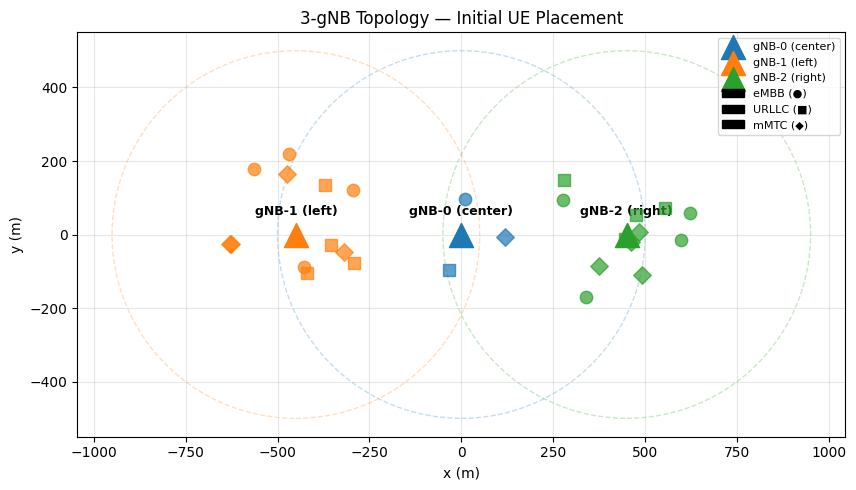

  UE  slice  serving        x        y
----------------------------------------
   0   eMBB        0     11.0     97.2
   1   eMBB        1   -563.8    179.0
   2   eMBB        1   -294.8    121.9
   3   eMBB        1   -467.8    217.8
   4   eMBB        1   -428.9    -88.0
   5   eMBB        2    275.4     92.9
   6   eMBB        2    596.8    -13.8
   7   eMBB        2    338.8   -170.6
   8   eMBB        2    620.9     58.9
   9  URLLC        0    -34.0    -96.1
  10  URLLC        1   -370.4    133.6
  11  URLLC        1   -419.5   -106.0
  12  URLLC        1   -355.1    -28.3
  13  URLLC        1   -293.1    -77.5
  14  URLLC        2    475.8     52.4
  15  URLLC        2    444.5    -13.4
  16  URLLC        2    555.0     71.7
  17  URLLC        2    278.4    149.7
  18   mMTC        0    119.6     -5.7
  19   mMTC        1   -318.0    -47.0
  20   mMTC        1   -629.3    -26.5
  21   mMTC        1   -475.3    163.8
  22   mMTC        1   -627.2    -25.6
  23   mMTC        2   

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

# gNB towers
gnb_pos = {int(g.id): (float(g.x), float(g.y)) for g in base_env.gnbs}
for gid, (gx, gy) in gnb_pos.items():
    ax.scatter(gx, gy, s=300, marker="^", color=GNB_COLORS[gid],
               zorder=5, label=GNB_LABELS[gid])
    ax.annotate(GNB_LABELS[gid], (gx, gy), textcoords="offset points",
                xytext=(0, 14), ha="center", fontsize=9, fontweight="bold")

# UEs coloured by serving gNB
for ue in base_env.get_all_ues():
    if ue.serving_gnb is None:
        color, marker = "gray", "x"
    else:
        color  = GNB_COLORS.get(int(ue.serving_gnb), "gray")
        marker = {"eMBB": "o", "URLLC": "s", "mMTC": "D"}.get(
            normalize_slice_type(getattr(ue, "slice_type", "eMBB")), "o"
        )
    ax.scatter(float(ue.x), float(ue.y), s=80, marker=marker,
               color=color, alpha=0.7, zorder=4)

# coverage circles (approximate)
for gid, (gx, gy) in gnb_pos.items():
    circle = plt.Circle((gx, gy), 500, color=GNB_COLORS[gid],
                         fill=False, linestyle="--", alpha=0.25)
    ax.add_patch(circle)

# legend for UE shapes
shape_legend = [
    mpatches.Patch(color="black", label="eMBB (●)"),
    mpatches.Patch(color="black", label="URLLC (■)"),
    mpatches.Patch(color="black", label="mMTC (◆)"),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + shape_legend,
          loc="upper right", fontsize=8)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("3-gNB Topology — Initial UE Placement")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# print UE table
print(f"{'UE':>4} {'slice':>6} {'serving':>8} {'x':>8} {'y':>8}")
print("-" * 40)
for ue in sorted(base_env.get_all_ues(), key=lambda u: int(u.id)):
    print(f"{int(ue.id):>4} {getattr(ue,'slice_type','?'):>6} "
          f"{str(ue.serving_gnb):>8} {float(ue.x):>8.1f} {float(ue.y):>8.1f}")

---
## 3 — Initial Load and Slice Counts

 gNB  slice     seeded   window-avg   UEs
------------------------------------------
   0   eMBB      0.200        0.000     1
   0  URLLC      0.200        0.000     1
   0   mMTC      0.200        0.000     1
   1   eMBB      0.850        0.000     4
   1  URLLC      0.850        0.000     4
   1   mMTC      0.850        0.000     4
   2   eMBB      0.850        0.000     4
   2  URLLC      0.850        0.000     4
   2   mMTC      0.850        0.000     4

  seeded     = get_slice_loads()               → PRB target set by _seed_case_prbs  [STATIC]
  window-avg = get_window_average_slice_loads() → actual radio utilization accumulator [DYNAMIC]
  (window-avg may be ~0 at step 0 before radio has run; it fills in after the first substeps)


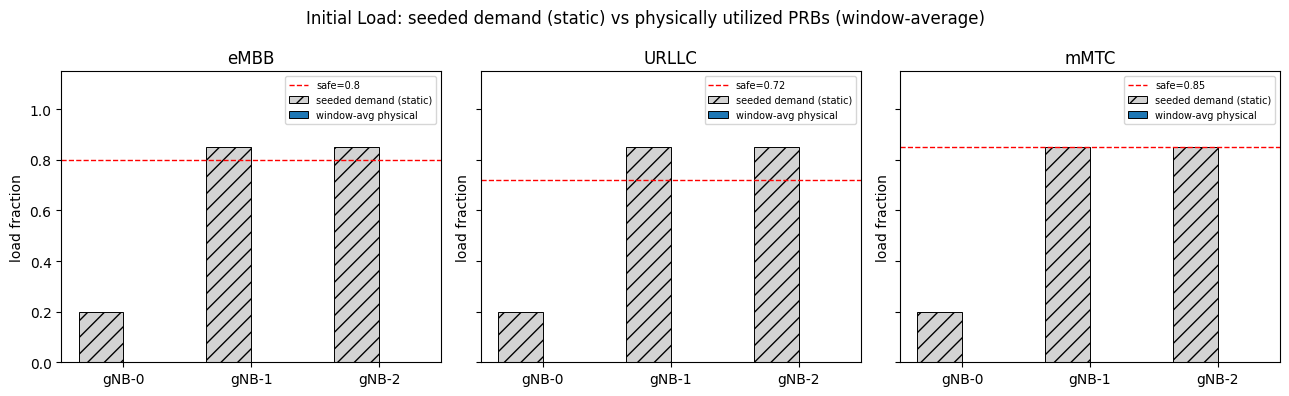

In [4]:
# Seeded demand target — injected by _seed_case_prbs() every step, STATIC per episode
seeded_loads = base_env.get_slice_loads()

# Physically utilized PRBs — window average of radio scheduler output, DYNAMIC
# This is what actually changes when UEs handover or SINR shifts
window_loads = base_env.get_window_average_slice_loads()

counts = {}
for ue in base_env.get_all_ues():
    if ue.serving_gnb is None or not ue.connected: continue
    k = (int(ue.serving_gnb), normalize_slice_type(getattr(ue, "slice_type", "eMBB")))
    counts[k] = counts.get(k, 0) + 1

print(f"{'gNB':>4} {'slice':>6} {'seeded':>10} {'window-avg':>12} {'UEs':>5}")
print("-" * 42)
for gid in GNB_IDS:
    for st in SLICE_TYPES:
        s   = float(seeded_loads.get((gid, st), 0.0))
        w   = float(window_loads.get((gid, st), 0.0))
        cnt = counts.get((gid, st), 0)
        print(f"{gid:>4} {st:>6} {s:>10.3f} {w:>12.3f} {cnt:>5}")

print("\n  seeded     = get_slice_loads()               → PRB target set by _seed_case_prbs  [STATIC]")
print("  window-avg = get_window_average_slice_loads() → actual radio utilization accumulator [DYNAMIC]")
print("  (window-avg may be ~0 at step 0 before radio has run; it fills in after the first substeps)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
x = np.arange(len(GNB_IDS))
bw = 0.35
for ax, st in zip(axes, SLICE_TYPES):
    s_vals = [float(seeded_loads.get((g, st), 0.0)) for g in GNB_IDS]
    w_vals = [float(window_loads.get((g, st), 0.0)) for g in GNB_IDS]
    ax.bar(x - bw/2, s_vals, bw, label="seeded demand (static)",
           color="lightgray", edgecolor="black", linewidth=0.7, hatch="//")
    ax.bar(x + bw/2, w_vals, bw, label="window-avg physical",
           color=[GNB_COLORS[g] for g in GNB_IDS], edgecolor="black", linewidth=0.7)
    safe = {"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85}.get(st, 0.80)
    ax.axhline(safe, color="red", linestyle="--", linewidth=1.0, label=f"safe={safe}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"gNB-{g}" for g in GNB_IDS])
    ax.set_ylim(0, 1.15); ax.set_title(f"{st}"); ax.set_ylabel("load fraction")
    ax.legend(fontsize=7)
fig.suptitle("Initial Load: seeded demand (static) vs physically utilized PRBs (window-average)")
plt.tight_layout(); plt.show()

---
## 4 — Upper Heuristic: Compute Directional Bias

`compute_upper_expert_directional_bias` reads live load / SLA / radio from `base_env`
and outputs `B[(src, tgt, slice)] ∈ [-1, +1]` for every directed pair.

Direction        eMBB    URLLC     mMTC
------------------------------------------
g0→g1          +0.812   +0.903   +0.765
g0→g2          +0.812   +0.903   +0.765
g1→g0          -1.000   +0.000   -0.485
g1→g2          +0.062   +0.181   +0.000
g2→g0          -1.000   -1.000   +0.000
g2→g1          +0.062   +0.181   +0.000


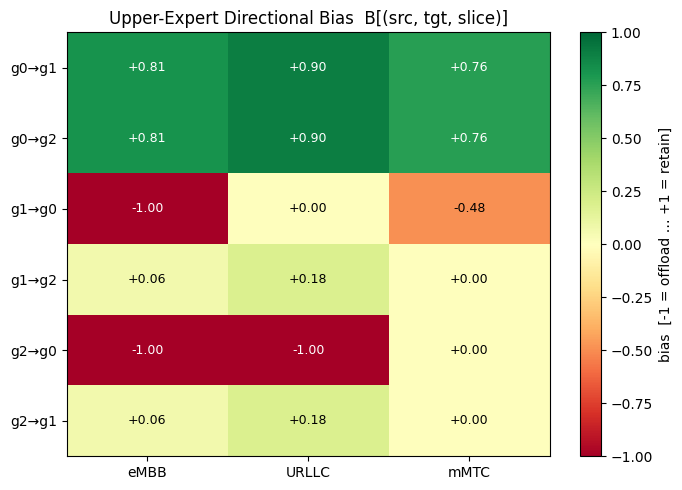

In [5]:
bias = compute_upper_expert_directional_bias(
    base_env,
    gnb_ids=GNB_IDS,
    neighbor_graph=NEIGHBORS,
    slice_types=SLICE_TYPES,
)

# Print table
print(f"{'Direction':<12} {'eMBB':>8} {'URLLC':>8} {'mMTC':>8}")
print("-" * 42)
for src in GNB_IDS:
    for tgt in NEIGHBORS[src]:
        vals = [f"{bias.get((src,tgt,st),0.0):+.3f}" for st in SLICE_TYPES]
        print(f"g{src}→g{tgt}        {vals[0]:>8} {vals[1]:>8} {vals[2]:>8}")

# Heatmap
directions = [(src, tgt) for src in GNB_IDS for tgt in NEIGHBORS[src]]
matrix = np.array([
    [bias.get((s, t, st), 0.0) for st in SLICE_TYPES]
    for s, t in directions
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(SLICE_TYPES))); ax.set_xticklabels(SLICE_TYPES)
ax.set_yticks(range(len(directions)))
ax.set_yticklabels([f"g{s}→g{t}" for s, t in directions])
for i in range(len(directions)):
    for j in range(len(SLICE_TYPES)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:+.2f}", ha="center", va="center", fontsize=9,
                color="black" if abs(val) < 0.6 else "white")
plt.colorbar(im, ax=ax, label="bias  [-1 = offload … +1 = retain]")
ax.set_title("Upper-Expert Directional Bias  B[(src, tgt, slice)]")
plt.tight_layout(); plt.show()

agent = SingleGNBHeuristicAgent(
    local_env,
    safe_load={"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85},
    bias_deadband=0.05,
)

print("Active bias on gNB-0 local_env:")
for (src, tgt, st), val in sorted(local_env.global_bias.items()):
    if src == 0:
        print(f"  g{src}→g{tgt} {st:<6}: {val:+.4f}")

# predict() now computes BOTH offsets (Gate 1) AND budgets (Gate 2)
action, _ = agent.predict(obs)

print("\n--- Gate 1: A3 offset (direction signal) ---")
print(f"{'direction':<12} {'bias':>8} {'offset (dB)':>12}")
print("-" * 35)
keys = [(nb, st) for nb in local_env.neighbor_ids for st in SLICE_TYPES]
for (nb, st), offset in zip(keys, action):
    bias_val = local_env.global_bias.get((0, nb, st), 0.0)
    print(f"  g0→g{nb} {st:<6}: {bias_val:>+8.3f} → {offset:>+10.1f} dB")

print("\n--- Gate 2: handover budget (bias × safe_load clamp) ---")
print(f"{'direction':<12} {'bias':>8} {'bias_budget':>12} {'safe_budget':>12} {'final':>8}")
print("-" * 55)
for nb in local_env.neighbor_ids:
    for st in SLICE_TYPES:
        b = local_env.global_bias.get((0, nb, st), 0.0)
        bgt = agent._budgets.get((nb, st), 0)
        # Recompute bias_budget and safe_budget for display
        import math
        strength = max(0.0, -b)
        n_ues = sum(1 for ue in base_env.get_all_ues()
                    if ue.connected and ue.serving_gnb is not None
                    and int(ue.serving_gnb) == 0
                    and normalize_slice_type(getattr(ue, "slice_type", "eMBB")) == st)
        bias_bgt = max(1, math.ceil(strength * n_ues - 1e-9)) if strength > 0.05 and n_ues > 0 else 0
        wl = base_env.get_window_average_slice_loads()
        load_src = float(wl.get((0, st), 0.0))
        per_ue_load = load_src / n_ues if n_ues > 0 and load_src > 0 else 0
        safe_lim = {"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85}[st]
        excess = max(0, load_src - safe_lim)
        safe_bgt = max(1, math.ceil(excess / per_ue_load - 1e-9)) if per_ue_load > 0 else bias_bgt
        print(f"  g0→g{nb} {st:<6}: {b:>+8.3f}  {bias_bgt:>12}  {safe_bgt:>12}  {bgt:>8}")

Active bias on gNB-0 local_env:
  g0→g1 URLLC : +0.9028
  g0→g1 eMBB  : +0.8125
  g0→g1 mMTC  : +0.7647
  g0→g2 URLLC : +0.9028
  g0→g2 eMBB  : +0.8125
  g0→g2 mMTC  : +0.7647

Heuristic agent action (proto-offsets):
  g0→g1 eMBB  : bias=+0.812  →  offset=+4.9 dB
  g0→g1 URLLC : bias=+0.903  →  offset=+5.4 dB
  g0→g1 mMTC  : bias=+0.765  →  offset=+4.6 dB
  g0→g2 eMBB  : bias=+0.812  →  offset=+4.9 dB
  g0→g2 URLLC : bias=+0.903  →  offset=+5.4 dB
  g0→g2 mMTC  : bias=+0.765  →  offset=+4.6 dB


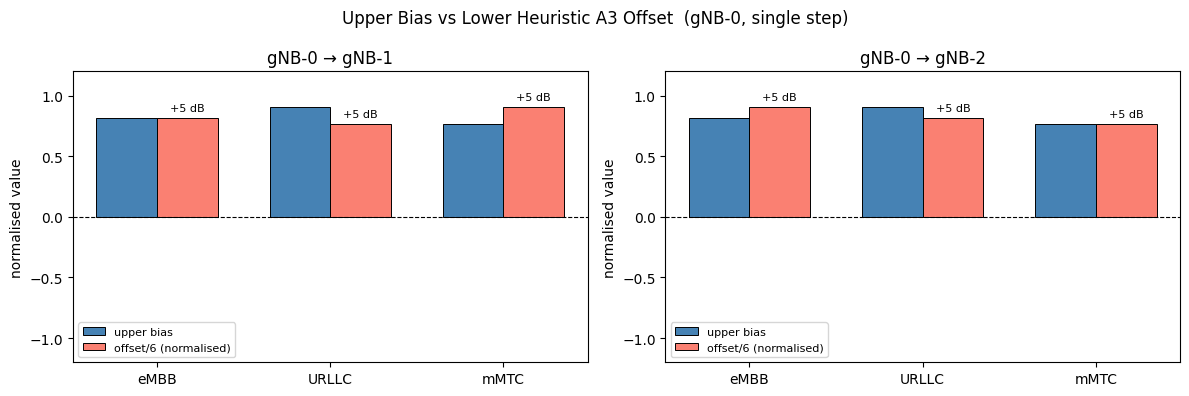

In [6]:
agent = SingleGNBHeuristicAgent(local_env)

print("Active bias on gNB-0 local_env:")
for (src, tgt, st), val in sorted(local_env.global_bias.items()):
    if src == 0:
        print(f"  g{src}→g{tgt} {st:<6}: {val:+.4f}")

action, _ = agent.predict(obs)

# Decode action back to (neighbor, slice) keys
print("\nHeuristic agent action (proto-offsets):")
keys = [(nb, st) for nb in local_env.neighbor_ids for st in SLICE_TYPES]
for (nb, st), offset in zip(keys, action):
    bias_val = local_env.global_bias.get((0, nb, st), 0.0)
    print(f"  g0→g{nb} {st:<6}: bias={bias_val:+.3f}  →  offset={offset:+.1f} dB")

# Bar chart: bias vs resulting offset per direction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, nb in enumerate(local_env.neighbor_ids):
    ax = axes[ax_idx]
    biases  = [local_env.global_bias.get((0, nb, st), 0.0) for st in SLICE_TYPES]
    offsets = [float(action[i * len(local_env.neighbor_ids) + ax_idx]) for i in range(len(SLICE_TYPES))]
    x = np.arange(len(SLICE_TYPES))
    w = 0.35
    b1 = ax.bar(x - w/2, biases,  w, label="upper bias",   color="steelblue", edgecolor="black", linewidth=0.7)
    b2 = ax.bar(x + w/2, [o/6 for o in offsets], w, label="offset/6 (normalised)",
                color="salmon", edgecolor="black", linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x); ax.set_xticklabels(SLICE_TYPES)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f"gNB-0 → gNB-{nb}")
    ax.set_ylabel("normalised value")
    ax.legend(fontsize=8)
    for bar, val in zip(b2, offsets):
        ax.text(bar.get_x() + bar.get_width()/2, val/6 + (0.06 if val/6 >= 0 else -0.10),
                f"{val:+.0f} dB", ha="center", fontsize=8)

fig.suptitle("Upper Bias vs Lower Heuristic A3 Offset  (gNB-0, single step)")
plt.tight_layout(); plt.show()

---
## 6 — Multi-Step Simulation Loop

Run one full episode.  The heuristic agent drives gNB-0; gNBs 1 and 2 are driven
by `strong_directional_heuristic_local_executor` inside the env.

We record load, offset, bias, handovers, and reward at every step.

In [7]:
obs, info = env.reset()
agent.reset()

history = {
    "step":           [],
    "reward":         [],
    # Physically utilized PRBs — window average from radio scheduler (DYNAMIC)
    "window_loads":   {(g, st): [] for g in GNB_IDS for st in SLICE_TYPES},
    # Seeded demand target — static per episode, kept only as reference
    "seeded_loads":   {(g, st): [] for g in GNB_IDS for st in SLICE_TYPES},
    "offsets":        {(nb, st): [] for nb in (1, 2) for st in SLICE_TYPES},
    "bias":           {(nb, st): [] for nb in (1, 2) for st in SLICE_TYPES},
    "ho_attempts":    [],
    "ho_successes":   [],
    "ho_failures":    [],
    "ho_ping_pongs":  [],
}

done = False
step = 0
while not done:
    action, _ = agent.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = bool(terminated or truncated)
    step += 1

    history["step"].append(step)
    history["reward"].append(float(reward))

    # Physically utilized PRBs — DYNAMIC: changes with handovers, SINR, scheduler
    win_loads  = base_env.get_window_average_slice_loads()
    # Seeded demand target — STATIC: set by _seed_case_prbs each step (reference only)
    seed_loads = dict(info.get("post_action_slice_loads", info.get("slice_loads", {})))

    for g in GNB_IDS:
        for st in SLICE_TYPES:
            history["window_loads"][(g, st)].append(float(win_loads.get((g, st), 0.0)))
            history["seeded_loads"][(g, st)].append(float(seed_loads.get((g, st), 0.0)))

    applied  = dict(info.get("applied_offsets", {}))
    rule_bias = dict(info.get("rule_bias", {}))
    for nb in (1, 2):
        for st in SLICE_TYPES:
            history["offsets"][(nb, st)].append(float(applied.get((nb, st), 0.0)))
            history["bias"][(nb, st)].append(
                float(rule_bias.get((0, nb, st), 0.0))
            )

    ho = dict(info.get("handover_stats", {}))
    history["ho_attempts"].append(int(ho.get("attempts", 0)))
    history["ho_successes"].append(int(ho.get("successes", 0)))
    history["ho_failures"].append(int(ho.get("failures", 0)))
    history["ho_ping_pongs"].append(int(ho.get("ping_pongs", 0)))

steps = history["step"]
print(f"Episode done — {len(steps)} steps")
print(f"Total reward : {sum(history['reward']):+.3f}")
print(f"Total HO att : {sum(history['ho_attempts'])}  succ={sum(history['ho_successes'])}  fail={sum(history['ho_failures'])}")

# Sanity check: window_loads should vary more than seeded_loads across steps
import statistics
for st in SLICE_TYPES:
    w_vals = history["window_loads"][(0, st)]
    s_vals = history["seeded_loads"][(0, st)]
    if len(w_vals) > 1:
        w_std = statistics.stdev(w_vals)
        s_std = statistics.stdev(s_vals)
        print(f"  gNB-0 {st}: window_loads std={w_std:.4f}  seeded_loads std={s_std:.4f}"
              f"  {'← dynamic ✓' if w_std > s_std else ''}")

[LocalA3 scenario] reset=2 name=mmtc_offload_embb_retain_urllc_neutral cases=[eMBB=retain, URLLC=neutral, mMTC=offload] loads=[g0:URLLC=0.60, g0:eMBB=0.20, g0:mMTC=0.90, g1:URLLC=0.45, g1:eMBB=0.85, g1:mMTC=0.20, g2:URLLC=0.45, g2:eMBB=0.85, g2:mMTC=0.20] bias=[g0→g1:URLLC=-0, g0→g1:eMBB=+1, g0→g1:mMTC=-0, g0→g2:URLLC=-0, g0→g2:eMBB=+1, g0→g2:mMTC=-0, g1→g0:URLLC=+0, g1→g0:eMBB=-1, g1→g0:mMTC=+1, g1→g2:URLLC=+0, g1→g2:eMBB=+0, g1→g2:mMTC=+0, g2→g0:URLLC=+0, g2→g0:eMBB=+0, g2→g0:mMTC=+1, g2→g1:URLLC=+0, g2→g1:eMBB=+0, g2→g1:mMTC=+0]
Episode done — 30 steps
Total reward : -28.304
Total HO att : 1  succ=1  fail=0
  gNB-0 eMBB: window_loads std=0.0269  seeded_loads std=0.1660  
  gNB-0 URLLC: window_loads std=0.0531  seeded_loads std=0.2820  
  gNB-0 mMTC: window_loads std=0.0280  seeded_loads std=0.2793  


---
## 7 — Plot: Load Evolution per gNB

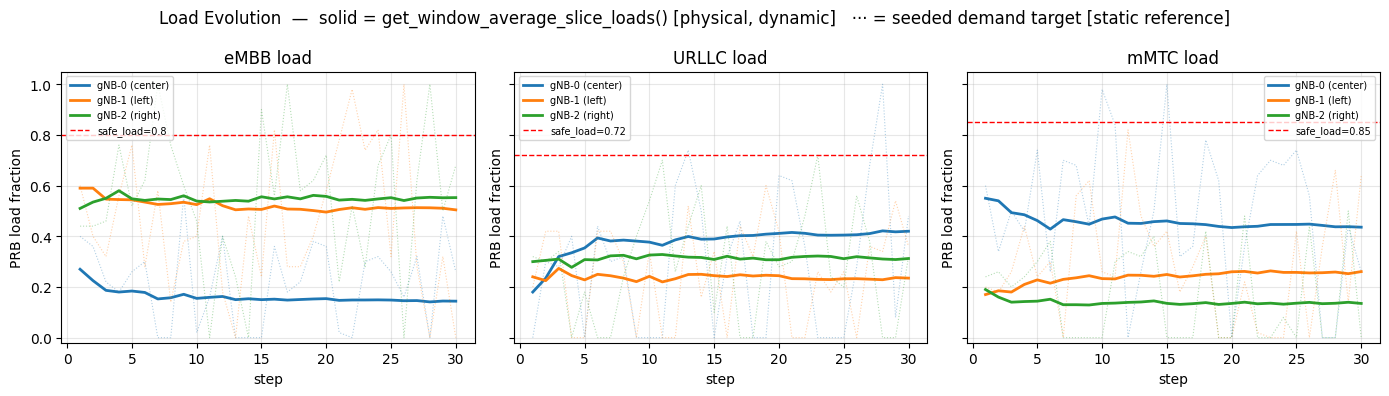

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, st in zip(axes, SLICE_TYPES):
    for gid in GNB_IDS:
        # Physically utilized — solid line, primary signal
        ax.plot(steps, history["window_loads"][(gid, st)],
                color=GNB_COLORS[gid], linewidth=2, label=GNB_LABELS[gid])
        # Seeded demand — light dotted, reference only (changes with balance_bias_cases scenario)
        ax.plot(steps, history["seeded_loads"][(gid, st)],
                color=GNB_COLORS[gid], linewidth=0.8, linestyle=":", alpha=0.35)
    safe = {"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85}.get(st, 0.80)
    ax.axhline(safe, color="red", linestyle="--", linewidth=1.0, label=f"safe_load={safe}")
    ax.set_title(f"{st} load")
    ax.set_xlabel("step")
    ax.set_ylabel("PRB load fraction")
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle(
    "Load Evolution  —  solid = get_window_average_slice_loads() [physical, dynamic]"
    "   ··· = seeded demand target [static reference]"
)
plt.tight_layout(); plt.show()

---
## 7b — Before vs After: Physical Load (window-average)

Compare the **first step** (before the heuristic has had time to act) against the
**last step** (after a full episode of bias-driven handovers).

The delta annotations show per-gNB load change; the imbalance table shows whether
the heuristic reduced spread across gNBs.

[LocalA3 scenario] reset=3 name=risky_embb_urllc_mmtc_neutral cases=[eMBB=risky_offload, URLLC=risky_offload, mMTC=neutral] loads=[g0:URLLC=0.90, g0:eMBB=0.90, g0:mMTC=0.60, g1:URLLC=0.82, g1:eMBB=0.82, g1:mMTC=0.45, g2:URLLC=0.82, g2:eMBB=0.82, g2:mMTC=0.45] bias=[g0→g1:URLLC=+0, g0→g1:eMBB=+0, g0→g1:mMTC=+0, g0→g2:URLLC=+0, g0→g2:eMBB=+0, g0→g2:mMTC=+0, g1→g0:URLLC=+0, g1→g0:eMBB=+0, g1→g0:mMTC=+0, g1→g2:URLLC=+0, g1→g2:eMBB=+0, g1→g2:mMTC=+0, g2→g0:URLLC=+0, g2→g0:eMBB=+0, g2→g0:mMTC=+0, g2→g1:URLLC=+0, g2→g1:eMBB=+0, g2→g1:mMTC=+0]
[LocalA3 scenario] reset=4 name=mmtc_offload_embb_retain_urllc_neutral cases=[eMBB=retain, URLLC=neutral, mMTC=offload] loads=[g0:URLLC=0.60, g0:eMBB=0.20, g0:mMTC=0.90, g1:URLLC=0.45, g1:eMBB=0.85, g1:mMTC=0.20, g2:URLLC=0.45, g2:eMBB=0.85, g2:mMTC=0.20] bias=[g0→g1:URLLC=-0, g0→g1:eMBB=+1, g0→g1:mMTC=-0, g0→g2:URLLC=-0, g0→g2:eMBB=+1, g0→g2:mMTC=-1, g1→g0:URLLC=+0, g1→g0:eMBB=-1, g1→g0:mMTC=+1, g1→g2:URLLC=+0, g1→g2:eMBB=+0, g1→g2:mMTC=+0, g2→g0:URLLC=

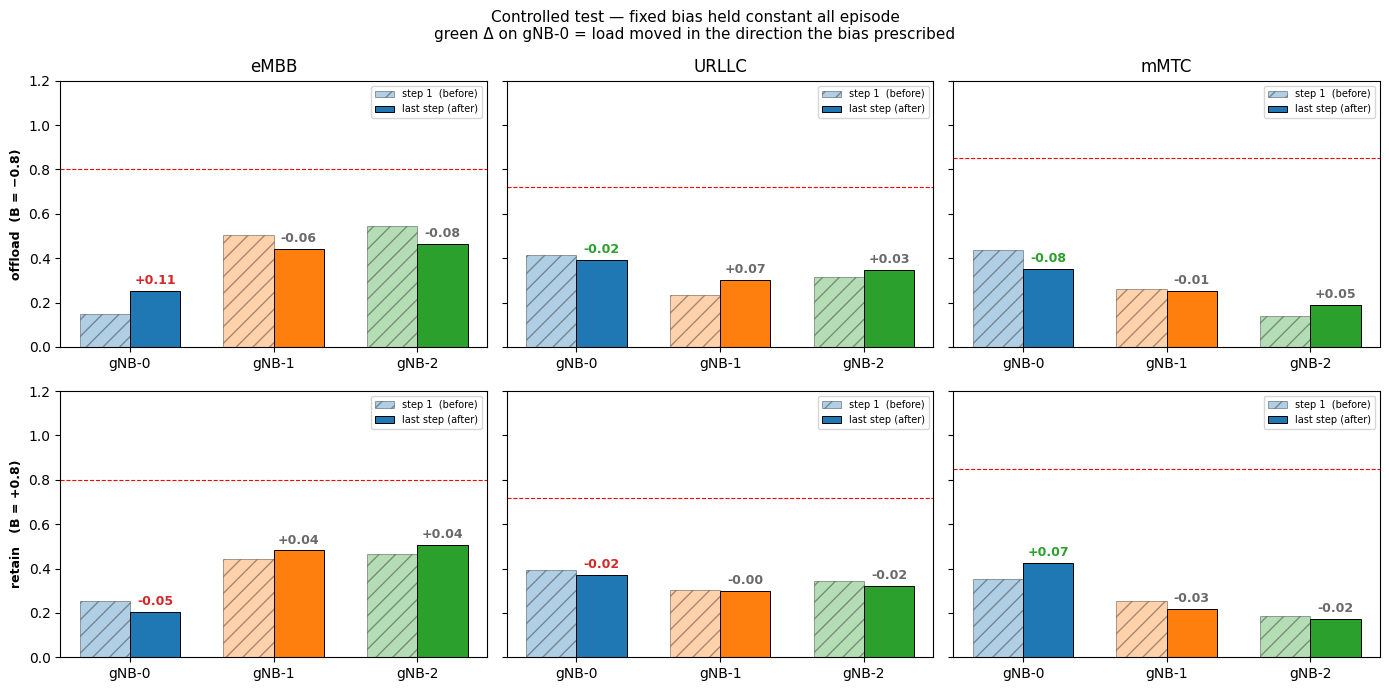

In [9]:
"""
Controlled validation: fix one bias value for the entire episode,
check that the offset sign matches, then check that gNB-0 physical
load moves in the expected direction.

offload  B=-0.8  → agent should output negative A3 offsets → UEs leave gNB-0
retain   B=+0.8  → agent should output positive A3 offsets → UEs stay at gNB-0
"""

CTRL_SCENARIOS = {
    "offload  (B = −0.8)": -0.8,
    "retain   (B = +0.8)": +0.8,
}

ctrl_results = {}

for label, bval in CTRL_SCENARIOS.items():
    obs, info = env.reset()
    agent.reset()

    # Build and lock in the fixed bias for gNB-0 outgoing directions only
    fixed_bias = {
        (0, nb, st): bval
        for nb in local_env.neighbor_ids
        for st in SLICE_TYPES
    }
    local_env.set_global_bias(fixed_bias)

    # Check what offset the heuristic immediately computes from this bias
    first_action, _ = agent.predict(obs)
    first_offsets = {
        (nb, st): float(first_action[i * len(SLICE_TYPES) + j])
        for i, nb in enumerate(local_env.neighbor_ids)
        for j, st in enumerate(SLICE_TYPES)
    }

    load_hist = {(g, st): [] for g in GNB_IDS for st in SLICE_TYPES}
    done = False
    while not done:
        action, _ = agent.predict(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        # Re-apply fixed bias each step (env._update_rule_bias() may override it)
        local_env.set_global_bias(fixed_bias)
        wl = base_env.get_window_average_slice_loads()
        for g in GNB_IDS:
            for st in SLICE_TYPES:
                load_hist[(g, st)].append(float(wl.get((g, st), 0.0)))

    ctrl_results[label] = {
        "bval":          bval,
        "first_offsets": first_offsets,
        "load_start":    {k: v[0]  if v else 0.0 for k, v in load_hist.items()},
        "load_end":      {k: v[-1] if v else 0.0 for k, v in load_hist.items()},
    }

# ── Offset verification ──────────────────────────────────────────────────────
print("=" * 62)
print("  Bias → Offset verification  (gNB-0 outgoing, first step)")
print("=" * 62)
for label, res in ctrl_results.items():
    print(f"\n  {label}  (B = {res['bval']:+.1f})")
    all_ok = True
    for nb in local_env.neighbor_ids:
        for st in SLICE_TYPES:
            off = res["first_offsets"][(nb, st)]
            if res["bval"] < 0:
                ok = off < -1.0
                verdict = "✓  negative offset → easier HO" if ok else "✗  expected negative"
            else:
                ok = off > +1.0
                verdict = "✓  positive offset → harder HO"  if ok else "✗  expected positive"
            if not ok: all_ok = False
            print(f"    g0→g{nb} {st:<6}: offset = {off:+.1f} dB   {verdict}")
    print(f"  {'ALL CORRECT ✓' if all_ok else 'MISMATCH — check heuristic logic'}")

# ── Before / After bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
bw = 0.35
x  = np.arange(len(GNB_IDS))

for row, (label, res) in enumerate(ctrl_results.items()):
    for col, st in enumerate(SLICE_TYPES):
        ax = axes[row, col]
        before = [res["load_start"][(g, st)] for g in GNB_IDS]
        after  = [res["load_end"]  [(g, st)] for g in GNB_IDS]

        ax.bar(x - bw/2, before, bw, label="step 1  (before)",
               color=[GNB_COLORS[g] for g in GNB_IDS],
               edgecolor="black", linewidth=0.7, alpha=0.35, hatch="//")
        ax.bar(x + bw/2, after,  bw, label="last step (after)",
               color=[GNB_COLORS[g] for g in GNB_IDS],
               edgecolor="black", linewidth=0.7)

        safe = {"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85}.get(st, 0.80)
        ax.axhline(safe, color="red", linestyle="--", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f"gNB-{g}" for g in GNB_IDS])
        ax.set_ylim(0, 1.20)
        ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label, fontsize=9, fontweight="bold")
        if row == 0:
            ax.set_title(f"{st}")

        # Delta annotations on the "after" bar
        for i, (b, a) in enumerate(zip(before, after)):
            delta = a - b
            # For gNB-0: offload→green if delta<0, retain→green if delta>0; neighbors inverse
            if i == 0:  # gNB-0 is the controlled one
                expected_decrease = res["bval"] < 0
                ok_color = "tab:green" if (expected_decrease and delta < -0.01) or \
                                          (not expected_decrease and delta > 0.01) else \
                           "tab:red"   if abs(delta) > 0.01 else "dimgray"
            else:
                ok_color = "dimgray"
            ax.text(x[i] + bw/2, max(a, 0) + 0.03, f"{delta:+.2f}",
                    ha="center", fontsize=9, fontweight="bold", color=ok_color)

fig.suptitle(
    "Controlled test — fixed bias held constant all episode\n"
    "green Δ on gNB-0 = load moved in the direction the bias prescribed",
    fontsize=11
)
plt.tight_layout()
plt.show()

---
## 7c — Two-Gate Budget Test

Verifies that the agent's two-gate design holds for three cases:

| Case | Bias | Expected Gate 1 | Expected Gate 2 |
|---|---|---|---|
| strong offload | B = -0.8 | negative A3 offset | budget = min(bias×N, excess/per_ue) ≥ 1 |
| weak offload   | B = -0.2 | small negative offset | budget smaller than strong case |
| retain         | B = +0.8 | positive A3 offset | budget = 0 (no releases) |

**Pass conditions checked per direction+slice:**
1. Offset sign matches bias sign
2. Handovers executed ≤ direction budget
3. Retain directions: 0 handovers regardless of radio conditions

In [10]:
import math as _math

TEST_CASES = {
    "strong offload (B=-0.8)": -0.8,
    "weak   offload (B=-0.2)": -0.2,
    "retain         (B=+0.8)": +0.8,
}

DEADBAND  = 0.05
SAFE_LIMS = {"eMBB": 0.80, "URLLC": 0.72, "mMTC": 0.85}

all_passed = True
results_table = []

for case_label, bval in TEST_CASES.items():
    obs, info = env.reset()
    agent.reset()

    fixed_bias = {(0, nb, st): bval
                  for nb in local_env.neighbor_ids
                  for st in SLICE_TYPES}
    local_env.set_global_bias(fixed_bias)

    # predict() computes both Gate 1 (offset) and Gate 2 (budget)
    action, _ = agent.predict(obs)
    budgets    = dict(agent._budgets)

    offset_map = {
        (nb, st): float(action[i * len(SLICE_TYPES) + j])
        for i, nb in enumerate(local_env.neighbor_ids)
        for j, st in enumerate(SLICE_TYPES)
    }

    # Snapshot source loads BEFORE the step (same state the heuristic used)
    wl = base_env.get_window_average_slice_loads()
    src_loads = {}
    for st in SLICE_TYPES:
        load = float(wl.get((0, st), 0.0))
        if load == 0.0 and hasattr(base_env, "estimate_slice_load"):
            load = float(base_env.estimate_slice_load(0, st))
        src_loads[st] = load

    # Run ONE step and count per-direction handovers from gNB-0
    dir_ho = {(nb, st): 0 for nb in local_env.neighbor_ids for st in SLICE_TYPES}
    ho_before = len(base_env.handover_events)
    obs, reward, terminated, truncated, info = env.step(action)
    ho_after  = len(base_env.handover_events)

    for evt in base_env.handover_events[ho_before:ho_after]:
        tgt = int(evt.get("to_gnb", -1))
        st  = normalize_slice_type(evt.get("slice_type", "eMBB"))
        key = (tgt, st)
        if key in dir_ho:
            dir_ho[key] += 1

    case_pass = True
    case_rows = []

    for nb in local_env.neighbor_ids:
        for st in SLICE_TYPES:
            key      = (nb, st)
            offset   = offset_map[key]
            budget   = budgets.get(key, 0)
            executed = dir_ho[key]
            load_src = src_loads[st]
            safe_lim = SAFE_LIMS[st]
            overloaded = load_src > safe_lim

            # Condition 1 — offset sign is consistent with bias AND source load.
            # coordinated_neighbor_offsets() is load-aware: if source is NOT
            # overloaded it correctly returns 0 even with a negative bias
            # (no pressure → no release offset needed).
            if abs(bval) > DEADBAND:
                if bval < 0:
                    if overloaded:
                        ok_sign = (offset < 0)        # must push to release
                    else:
                        ok_sign = (offset <= 0)       # 0 is correct, < 0 is also fine
                else:
                    ok_sign = (offset > 0)            # retain → always push positive
            else:
                ok_sign = True

            # Condition 2 — budget gate: never execute more than the computed budget
            ok_budget = (executed <= budget)

            # Condition 3 — retain: positive bias must block all gNB-0 releases
            ok_retain = (executed == 0) if bval > DEADBAND else True

            row_pass = ok_sign and ok_budget and ok_retain
            case_pass = case_pass and row_pass
            verdict = "PASS" if row_pass else "FAIL"
            note = f"load={load_src:.2f} safe={safe_lim} {'OVER' if overloaded else 'ok'}"
            case_rows.append((case_label, f"g0->g{nb} {st}", bval, offset, budget, executed, verdict, note))

    all_passed = all_passed and case_pass
    results_table.extend(case_rows)
    print(f"{'[PASS]' if case_pass else '[FAIL]'}  {case_label}")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f"{'case':<28} {'direction':<14} {'bias':>6} {'offset':>8} {'budget':>8} {'exec':>6}  {'src load':>10}  result")
print("-" * 96)
for (case_label, direction, bval, offset, budget, executed, verdict, note) in results_table:
    marker = "  <-- FAIL" if verdict == "FAIL" else ""
    print(f"  {case_label:<26} {direction:<14} {bval:>+6.2f} {offset:>+8.1f}  {budget:>7}  {executed:>5}  {note:>14}  {verdict}{marker}")

print()
print("=" * 55)
print(f"  Overall: {'ALL TESTS PASSED' if all_passed else 'SOME TESTS FAILED'}")
print("=" * 55)
print()
print("Note: offset=0 with bias<0 is CORRECT when source load < safe_load")
print("      (coordinated_neighbor_offsets is load-aware — no pressure → no release)")

[LocalA3 scenario] reset=5 name=urllc_offload_embb_neutral_mmtc_retain cases=[eMBB=neutral, URLLC=offload, mMTC=retain] loads=[g0:URLLC=0.90, g0:eMBB=0.60, g0:mMTC=0.20, g1:URLLC=0.20, g1:eMBB=0.45, g1:mMTC=0.85, g2:URLLC=0.20, g2:eMBB=0.45, g2:mMTC=0.85] bias=[g0→g1:URLLC=-0, g0→g1:eMBB=-0, g0→g1:mMTC=+1, g0→g2:URLLC=-1, g0→g2:eMBB=-0, g0→g2:mMTC=+1, g1→g0:URLLC=+1, g1→g0:eMBB=+0, g1→g0:mMTC=-0, g1→g2:URLLC=+0, g1→g2:eMBB=+0, g1→g2:mMTC=+0, g2→g0:URLLC=+1, g2→g0:eMBB=+0, g2→g0:mMTC=-0, g2→g1:URLLC=+0, g2→g1:eMBB=+0, g2→g1:mMTC=+0]
[PASS]  strong offload (B=-0.8)
[LocalA3 scenario] reset=6 name=embb_offload_urllc_retain_mmtc_neutral cases=[eMBB=offload, URLLC=retain, mMTC=neutral] loads=[g0:URLLC=0.20, g0:eMBB=0.90, g0:mMTC=0.60, g1:URLLC=0.85, g1:eMBB=0.20, g1:mMTC=0.45, g2:URLLC=0.85, g2:eMBB=0.20, g2:mMTC=0.45] bias=[g0→g1:URLLC=+1, g0→g1:eMBB=-1, g0→g1:mMTC=+0, g0→g2:URLLC=+1, g0→g2:eMBB=-0, g0→g2:mMTC=+0, g1→g0:URLLC=-1, g1→g0:eMBB=+1, g1→g0:mMTC=+0, g1→g2:URLLC=+0, g1→g2:eMBB=+0,

---
## 8 — Plot: Bias and Applied A3 Offset (gNB-0 directions)

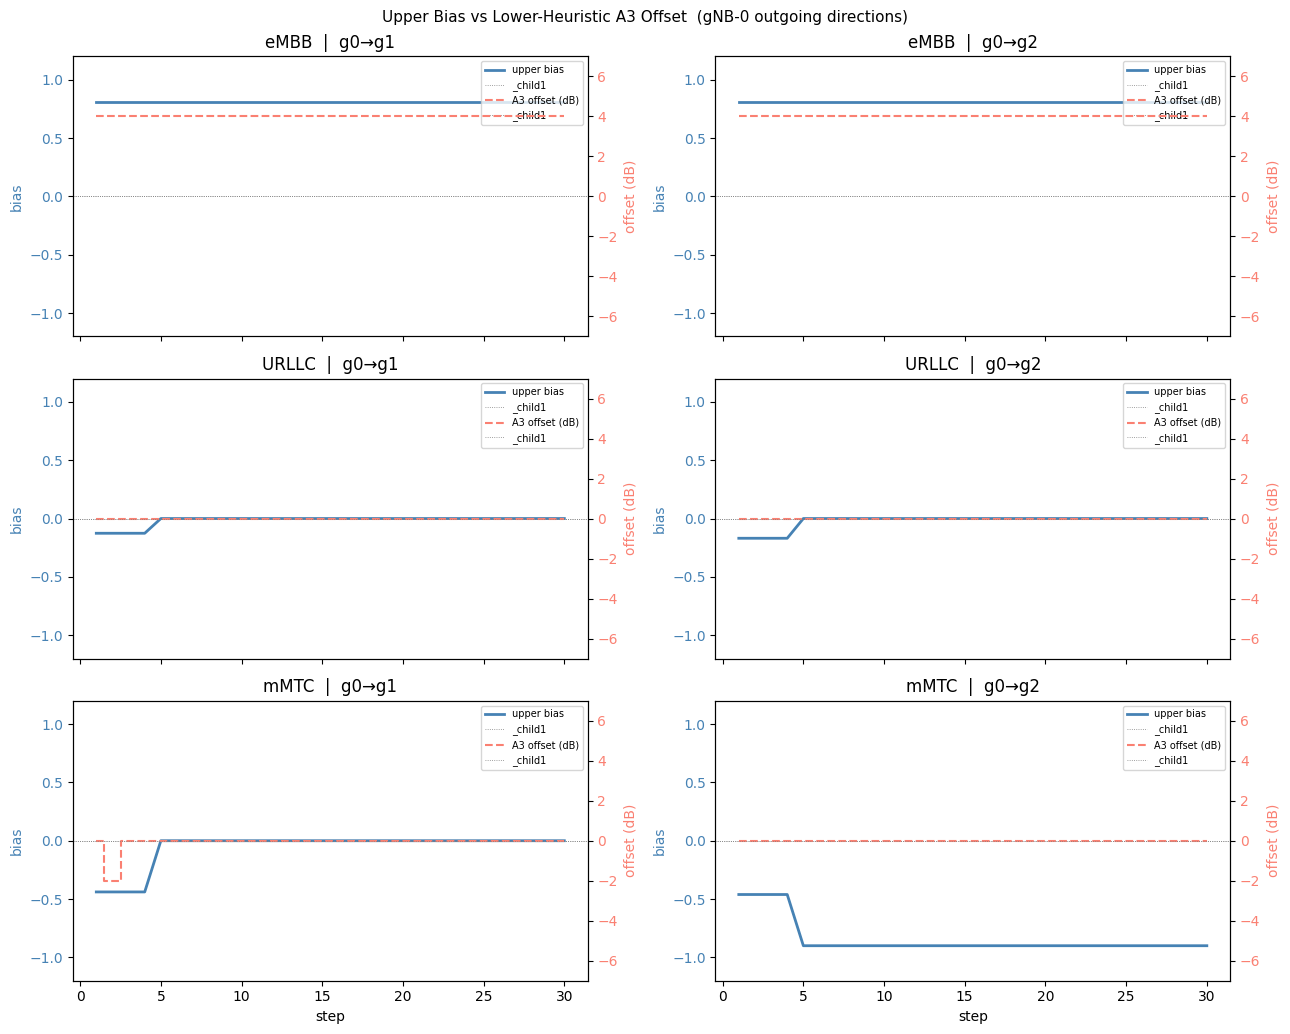

In [11]:
fig, axes = plt.subplots(len(SLICE_TYPES), 2, figsize=(13, 3.5 * len(SLICE_TYPES)),
                          sharex=True)

for row, st in enumerate(SLICE_TYPES):
    for col, nb in enumerate((1, 2)):
        ax = axes[row, col]
        bias_vals   = history["bias"][(nb, st)]
        offset_vals = history["offsets"][(nb, st)]

        ax2 = ax.twinx()
        ax.plot(steps, bias_vals,   color="steelblue",  linewidth=2, label="upper bias")
        ax2.step(steps, offset_vals, color="salmon",   linewidth=1.5, where="mid",
                 linestyle="--", label="A3 offset (dB)")

        ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
        ax2.axhline(0, color="gray", linewidth=0.6, linestyle=":")

        ax.set_ylabel("bias", color="steelblue")
        ax2.set_ylabel("offset (dB)", color="salmon")
        ax.set_ylim(-1.2, 1.2)
        ax2.set_ylim(-7, 7)
        ax.set_title(f"{st}  |  g0→g{nb}")
        ax.tick_params(axis="y", labelcolor="steelblue")
        ax2.tick_params(axis="y", labelcolor="salmon")

        lines  = ax.get_lines()  + ax2.get_lines()
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, fontsize=7, loc="upper right")

for col in range(2):
    axes[-1, col].set_xlabel("step")

fig.suptitle("Upper Bias vs Lower-Heuristic A3 Offset  (gNB-0 outgoing directions)",
             fontsize=11)
plt.tight_layout(); plt.show()

---
## 9 — Plot: Handover Events and Reward

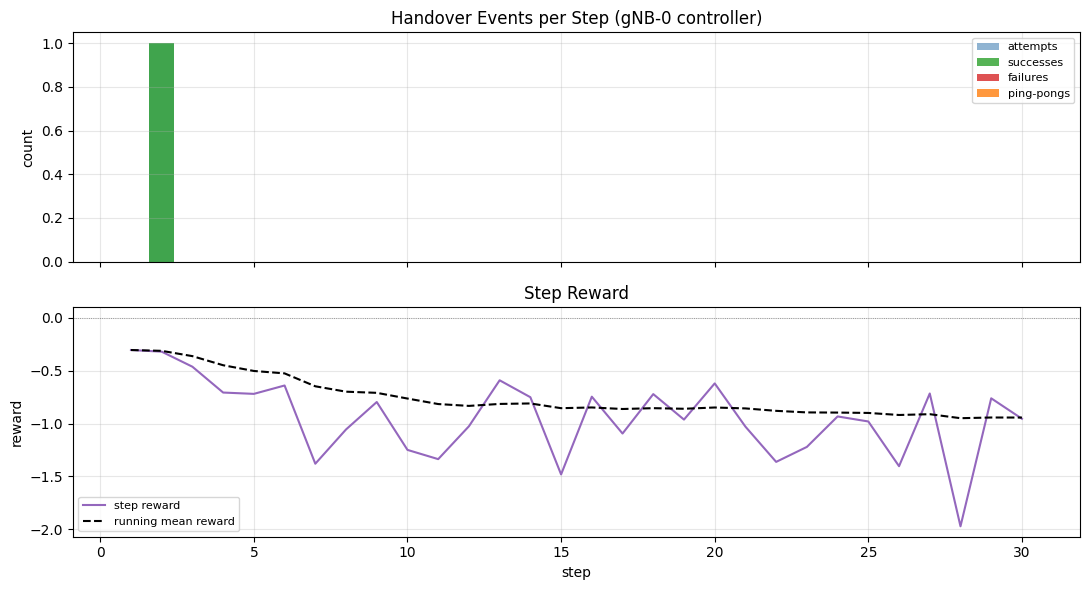

Total HO attempts  : 1
Total HO successes : 1
Total HO failures  : 0
Total ping-pongs   : 0
Episode return     : -28.304


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.bar(steps, history["ho_attempts"],  label="attempts",  color="steelblue", alpha=0.6)
ax1.bar(steps, history["ho_successes"], label="successes", color="tab:green", alpha=0.8)
ax1.bar(steps, history["ho_failures"],  label="failures",  color="tab:red",   alpha=0.8)
ax1.bar(steps, history["ho_ping_pongs"],label="ping-pongs",color="tab:orange",alpha=0.8)
ax1.set_ylabel("count")
ax1.set_title("Handover Events per Step (gNB-0 controller)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(steps, history["reward"], color="tab:purple", linewidth=1.5, label="step reward")
ax2.plot(steps, np.cumsum(history["reward"]) / np.arange(1, len(steps)+1),
         color="black", linewidth=1.5, linestyle="--", label="running mean reward")
ax2.axhline(0, color="gray", linewidth=0.6, linestyle=":")
ax2.set_ylabel("reward")
ax2.set_xlabel("step")
ax2.set_title("Step Reward")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Total HO attempts  : {sum(history['ho_attempts'])}")
print(f"Total HO successes : {sum(history['ho_successes'])}")
print(f"Total HO failures  : {sum(history['ho_failures'])}")
print(f"Total ping-pongs   : {sum(history['ho_ping_pongs'])}")
print(f"Episode return     : {sum(history['reward']):+.3f}")

---
## 10 — Sweep: Bias Magnitude vs Resulting Offset (static)

Shows the deterministic mapping `B → A3 offset` produced by
`coordinated_neighbor_offsets()` as source load varies.

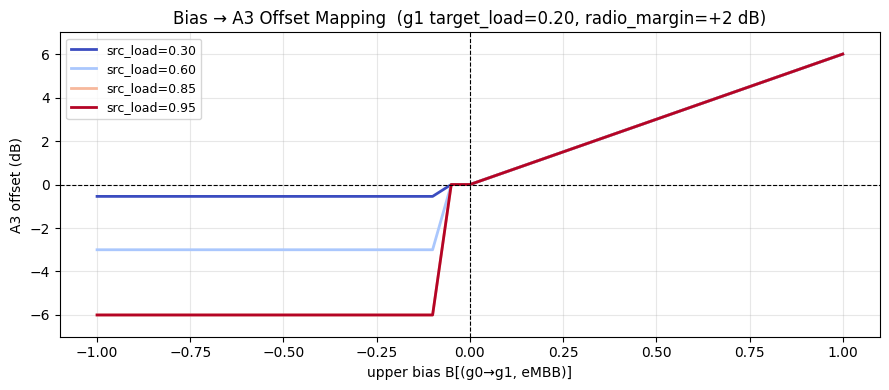

In [13]:
from two_neighbor_offset_heuristic import coordinated_neighbor_offsets

bias_vals  = np.linspace(-1.0, 1.0, 41)
src_loads  = [0.30, 0.60, 0.85, 0.95]
tgt_load   = 0.20

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(src_loads)))

for src_load, color in zip(src_loads, colors):
    offsets = []
    for b in bias_vals:
        result = coordinated_neighbor_offsets(
            source_id=0,
            neighbor_ids=[1],
            slice_types=["eMBB"],
            directional_bias={(0, 1, "eMBB"): float(b)},
            useful_load={(0, "eMBB"): src_load, (1, "eMBB"): tgt_load},
            best_radio_margin_db={(1, "eMBB"): 2.0},
        )
        offsets.append(float(result.get((1, "eMBB"), 0.0)))
    ax.plot(bias_vals, offsets, linewidth=2, color=color,
            label=f"src_load={src_load:.2f}")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("upper bias B[(g0→g1, eMBB)]")
ax.set_ylabel("A3 offset (dB)")
ax.set_title("Bias → A3 Offset Mapping  (g1 target_load=0.20, radio_margin=+2 dB)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-7, 7)
plt.tight_layout(); plt.show()

---
## Summary

| Stage | Component | Role |
|---|---|---|
| Upper heuristic | `compute_upper_expert_directional_bias` | Reads loads/SLA/radio → outputs B[(src,tgt,slice)] |
| Lower heuristic | `SingleGNBHeuristicAgent.predict()` | Reads B + live env → outputs A3 offsets for gNB-0 |
| Opponents | `strong_directional_heuristic_local_executor` | Same logic vectorised for gNBs 1 and 2 |
| Execution | `LocalA3OffsetEnv._execute_a3_handovers()` | Fires A3 rule, moves UEs |

The offset mapping (cell 10) shows:
- **negative bias → negative offset** (proportional to source pressure and bias magnitude)
- **neutral bias → 0 dB** (no A3 pressure in either direction)
- **positive bias → positive offset** (retain, scaled by 6·bias)
- **high source load amplifies release** for the same negative bias value